# Conférences Python Master TIDE #2

## A) US baby names

Télécharger le dataset national des prénoms US :
- Site : https://www.ssa.gov/oact/babynames/limits.html
- Fichier : https://www.ssa.gov/oact/babynames/names.zip

**Data Preparation**
- Avec une boucle et en utilisant la fonction `concat()` de **pandas** constituer un DataFrame avec l'ensemble des fichiers en ajoutant une colonne avec l'année.
- Ordre et noms des colonnes du DataFrame créé : "year", "name", "gender", "births"

**Data Analysis**
- Quel est le top 16 de la fréquence des prénoms dans le fichier ? Expliquer.
- Calculer la fréquence des genres dans le fichier. Expliquer.
- Ecrire une fonction qui affiche l'évolution des naissances d'un prénom et d'un genre dans le temps.
- Calculer l'évolution du nombre de naissances par année et par genre et afficher un graphique.
- Calculer l'évolution de la diversité des prénoms par année et par genre et afficher un graphique.

**Data Viz**
- Quels sont les 10 prénoms qui ont été les plus donnés.
- Produire un graphique de type `stripplot` avec en x les naissances, en y les 10 prénoms les plus donnés et une couleur différente par nuages de points.

## B) Prénoms français

Télécharger le dataset Fichiers France hors Mayotte de l'INSEE :
- https://www.insee.fr/fr/statistiques/7633685
- https://www.insee.fr/fr/statistiques/fichier/7633685/nat2022_csv.zip

L'idée est de charger les données et ensuite de les conformer au DataFrame des prénoms US. Ainsi, toute manipulation sur le DataFrame des prénoms US pourra être directement réutilisée avec le DataFrame des prénoms français.

**Data Preparation**
- Charger les données dans un DataFrame.
- Utiliser les mêmes noms de colonnes que pour le DataFrame US.
- Eliminer les données inutilisables et les prénoms d'une seule lettre.
- Passer les prénoms en minuscules sauf les initiales qui doivent rester en majuscules. Attention aux prénoms composés.
- Utiliser les mêmes catégories pour le genre.
- Passer les nombres de naissances en entiers.
- Trier le DataFrame à l'identique : années croissantes, genres croissants, naissances décroissantes, prénoms croissants.
- Remettre un index allant de 0 à N-1.

**Data Analysis**
- Ecrire une fonction qui affiche l'évolution des naissances d'un prénom dans le temps.
- Calculer l'évolution du nombre de naissances par année et par genre et afficher un graphique.
- Calculer l'évolution de la diversité des prénoms par année et par genre et afficher un graphique.

## C) Villes du monde et pays

Télécharger le dataset avec les villes du monde de plus de 500 habitants :
- http://www.geonames.org/
- http://download.geonames.org/export/dump/cities500.zip


**Data Preparation**
- Dans un premier temps, charger les données dans un DataFrame avec comme noms de colonnes <code>['geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude', 'feature class', 'feature code', 'country code', 'cc2', 'admin1 code', 'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation', 'dem', 'timezone', 'modification date']</code>
- On obtient un warning sur des types mixtes : parmi les colonnes qui sont des chaînes de caractères, quelles sont celles qui comportent également des nombres ? (appliquer la méthode de chaîne `isdigit()` sur les colonnes de type `object`).
- Compter le nombre de valeurs manquantes dans chaque colonne : quelle colonnes ne devraient pas avoir de valeurs manquantes ?
- Appliquer `describe()` sur le DataFrame complet, quelle valeur semble être également une valeur manquante ?
- Recharger les données en passant en `str` les colonnes mixtes et en précisant les valeurs manquantes.

**Split-apply-combine strategy**
- Ecrire une fonction qui trouve le nombre de `alternatenames` de chaque ville.
```python
def average_alternate_names(group):
    pass
```
- Calculer la moyenne du nombre de `alternatenames` par `feature code`.

**Jointure**

- Charger le tableau de la page https://www.geonames.org/countries/ avec la fonction **pandas** <code>read_html</code> en prenant garde aux valeurs manquantes par défaut.
- Joindre le DataFrame des villes avec celui des pays.
- Ecrire une fonction qui retourne le nom de la ville la plus peuplée et la tester sur le DataFrame obtenu.
- Appliquer la fonction en groupant par continent.

&copy; Francis Wolinski 2023

In [ ]:
import os
os.listdir("data/names")

In [ ]:
import glob
glob.glob("data/names/*.txt")

In [5]:
import pandas as pd

In [8]:
dfs = []

for year in range(1880, 2023):
    filename = f"data/names/yob{year}.txt"
    csv = pd.read_csv(filename, header=None, names=["name", "gender", "births"])
    csv["year"] = year
    dfs.append(csv)
    
df = pd.concat(dfs, ignore_index=True)
df = df[["year", "name", "gender", "births"]]
df

,year,name,gender,births
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
...,...,...,...,...
2085153,2022,Zuberi,M,5
2085154,2022,Zydn,M,5
2085155,2022,Zylon,M,5
2085156,2022,Zymeer,M,5


In [9]:
df["name"].value_counts().head(16)

Jean       286
Lee        286
John       286
Leslie     286
Joseph     286
William    286
James      286
Tommie     286
Marion     286
Jessie     286
Ollie      286
Johnnie    286
Sidney     286
Jesse      286
Francis    286
Charles    285
Name: name, dtype: int64

In [10]:
df["gender"].value_counts()

F    1227795
M     857363
Name: gender, dtype: int64

In [14]:
def plot_name(name, gender):
    selection = df.loc[(df["name"] == name) & (df["gender"] == gender)]
    selection.plot.line(x="year", y="births", title=f"Evolution des naissances de {name} ({gender})")

In [19]:
def plot_name(name, gender):
    (df
     .loc[(df["name"] == name) & (df["gender"] == gender)]
     .plot
     .line(x="year", y="births", title=f"Evolution des naissances de {name} ({gender})")
    )

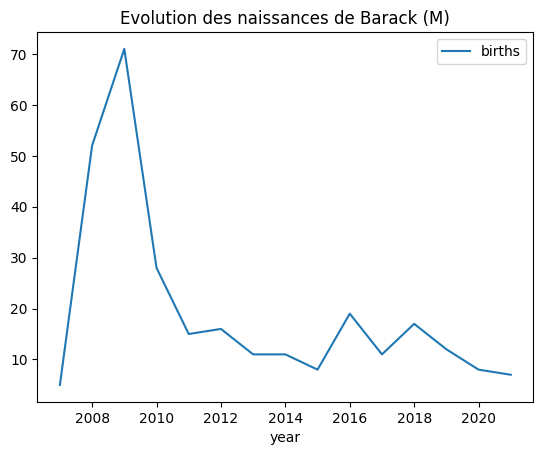

In [17]:
plot_name("Barack", "M")

In [23]:
df.groupby(["year", "gender"], as_index=False)["births"].sum().head()

,year,gender,births
0,1880,F,90994
1,1880,M,110490
2,1881,F,91953
3,1881,M,100737
4,1882,F,107847


In [25]:
df.groupby(["year", "gender"])["births"].sum().unstack()

gender,F,M
year,,
1880,90994,110490
1881,91953,100737
1882,107847,113686
1883,112320,104625
1884,129019,114442
...,...,...
2018,1698373,1813377
2019,1675139,1790682
2020,1612393,1721588


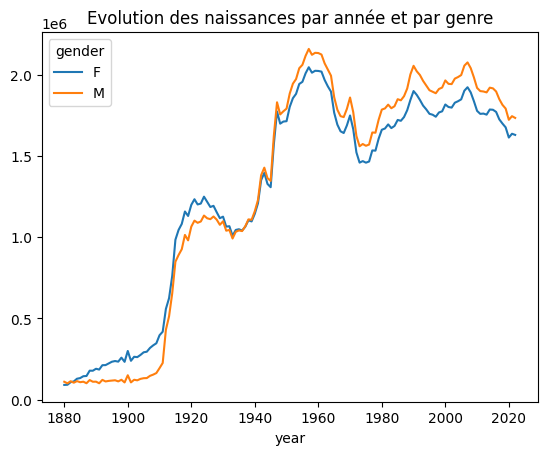

In [32]:
(df
 .pivot_table(index="year",
               columns="gender",
               values="births",
               aggfunc="sum")
 .plot
 .line(title="Evolution des naissances par année et par genre")
);

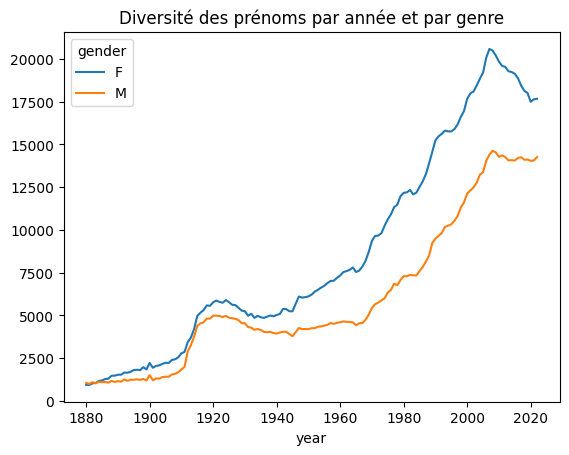

In [37]:
(df
 .pivot_table(index="year",
               columns="gender",
               values="name",
               aggfunc="count")
 .plot
 .line(title="Diversité des prénoms par année et par genre")
);

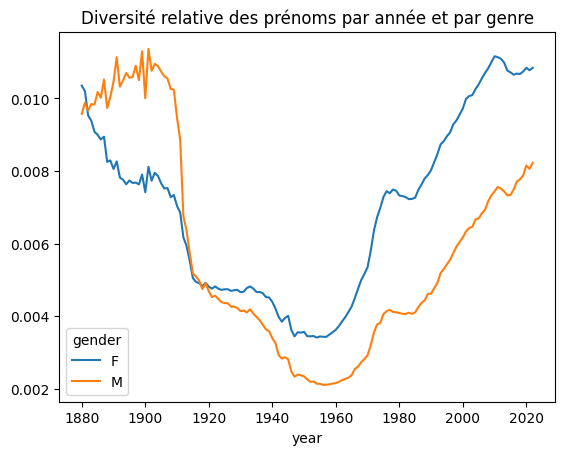

In [40]:
tab1 = df.pivot_table(index="year",
               columns="gender",
               values="births",
               aggfunc="sum")
tab2 = df.pivot_table(index="year",
               columns="gender",
               values="name",
               aggfunc="count")

tab2.div(tab1, axis=0).plot.line(title="Diversité relative des prénoms par année et par genre");

In [46]:
top10 = (df
 .pivot_table(index="name",
               values="births",
               aggfunc="sum")
 .nlargest(10, "births")
 .index
)
top10

Index(['James', 'John', 'Robert', 'Michael', 'William', 'Mary', 'David',
       'Joseph', 'Richard', 'Charles'],
      dtype='object', name='name')

In [48]:
import seaborn as sns
sns.set()

In [50]:
selection = df.loc[df["name"].isin(top10)]
selection

,year,name,gender,births
0,1880,Mary,F,7065
228,1880,John,F,46
286,1880,William,F,30
343,1880,James,F,22
514,1880,Robert,F,12
...,...,...,...,...
2070932,2022,Joseph,M,7771
2070933,2022,David,M,7741
2070952,2022,Charles,M,5889
2070986,2022,Robert,M,4051


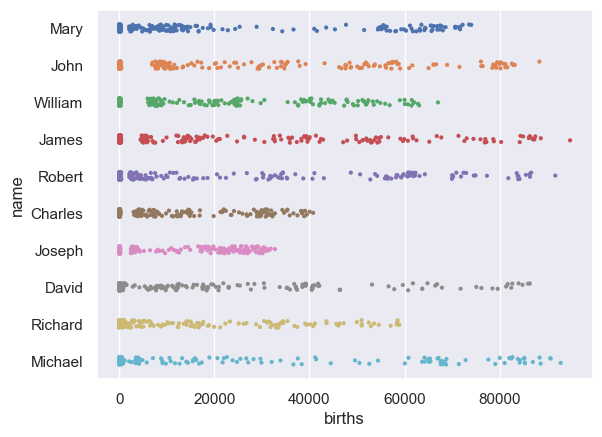

In [54]:
sns.stripplot(data=selection, x="births", y="name", hue="name", size=3, legend=False);

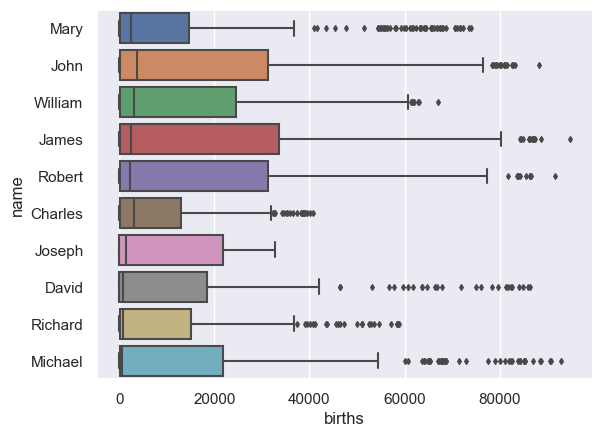

In [60]:
sns.boxplot(data=selection, x="births", y="name", fliersize=3);

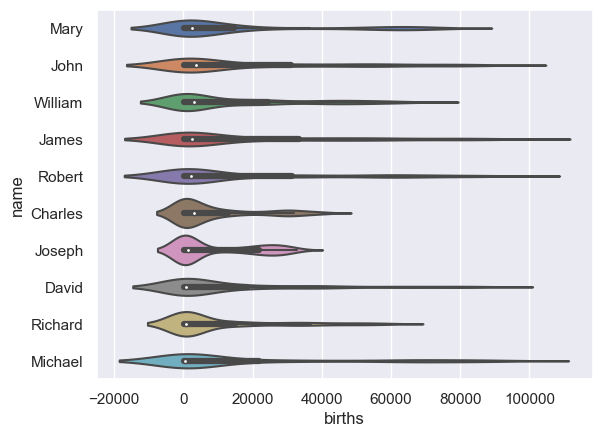

In [61]:
sns.violinplot(data=selection, x="births", y="name", fliersize=3);

In [85]:
df = pd.read_csv("data/nat2022_csv.zip", sep=";")
df = df.set_axis(["gender", "name", "year", "births"], axis=1)
df = df.loc[(df["name"] != "_PRENOMS_RARES") & df["year"].str.contains("^\d{4}$") & (df["name"].str.len() > 1)]
df["gender"] = df["gender"].map({1:"M", 2:"F"})
df["year"] = df["year"].astype(int)
df["name"] = df["name"].str.title()
df = df[["year", "name", "gender", "births"]]
df = df.sort_values(["year", "gender", "births", "name"], ascending=[True, True, False, True])
df = df.reset_index(drop=True)
df

,year,name,gender,births
0,1900,Marie,F,48713
1,1900,Jeanne,F,13981
2,1900,Marguerite,F,8058
3,1900,Germaine,F,6981
4,1900,Louise,F,6696
...,...,...,...,...
663917,2022,Éliano,M,3
663918,2022,Élohan,M,3
663919,2022,Éphraïm,M,3
663920,2022,Îmran,M,3


In [83]:
df.loc[df["name"].str.contains("-")]

,gender,name,year,births
357,M,Ab-Del,1951,3
358,M,Ab-Del,1952,3
359,M,Ab-Del,1961,4
360,M,Ab-Del,1967,3
361,M,Ab-Del,1969,3
...,...,...,...,...
688221,F,Victoria-Lynn,2006,3
698131,F,Yves-Lise,1959,3
698132,F,Yves-Lise,1960,3
698133,F,Yves-Lise,1969,3


In [72]:
df["gender"].unique()

array([1, 2], dtype=int64)

In [69]:
df.loc[df["year"].str.contains("^\d{4}$")]

,gender,name,year,births
0,1,_PRENOMS_RARES,1900,1249
1,1,_PRENOMS_RARES,1901,1342
2,1,_PRENOMS_RARES,1902,1330
3,1,_PRENOMS_RARES,1903,1286
4,1,_PRENOMS_RARES,1904,1430
...,...,...,...,...
703001,2,ZYNEB,2018,5
703002,2,ZYNEB,2019,7
703003,2,ZYNEB,2020,8
703004,2,ZYNEB,2021,6


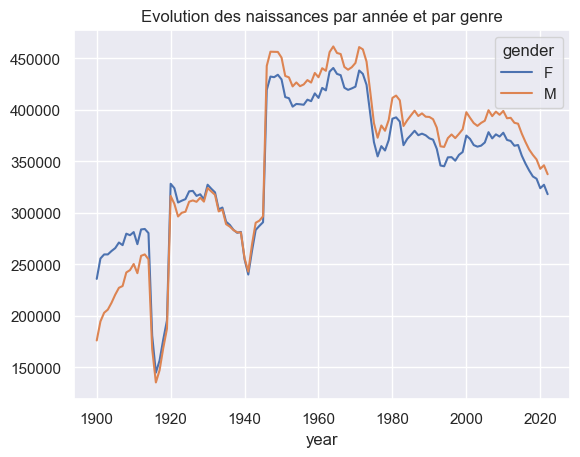

In [86]:
(df
 .pivot_table(index="year",
               columns="gender",
               values="births",
               aggfunc="sum")
 .plot
 .line(title="Evolution des naissances par année et par genre")
);

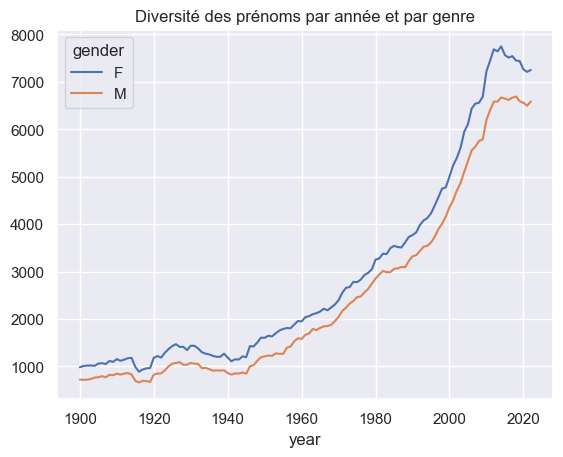

In [87]:
(df
 .pivot_table(index="year",
               columns="gender",
               values="name",
               aggfunc="count")
 .plot
 .line(title="Diversité des prénoms par année et par genre")
);

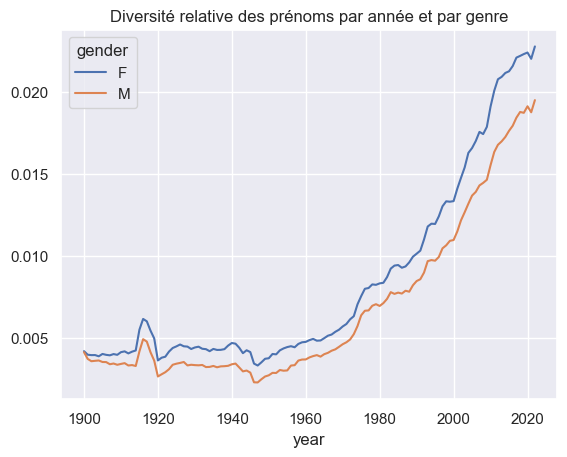

In [88]:
tab1 = df.pivot_table(index="year",
               columns="gender",
               values="births",
               aggfunc="sum")
tab2 = df.pivot_table(index="year",
               columns="gender",
               values="name",
               aggfunc="count")

tab2.div(tab1, axis=0).plot.line(title="Diversité relative des prénoms par année et par genre");

In [89]:
top10 = (df
 .pivot_table(index="name",
               values="births",
               aggfunc="sum")
 .nlargest(10, "births")
 .index
)
top10

Index(['Marie', 'Jean', 'Pierre', 'Michel', 'André', 'Jeanne', 'Philippe',
       'Louis', 'René', 'Alain'],
      dtype='object', name='name')

In [90]:
selection = df.loc[df["name"].isin(top10)]
selection

,year,name,gender,births
0,1900,Marie,F,48713
1,1900,Jeanne,F,13981
388,1900,André,F,16
464,1900,Pierre,F,11
572,1900,Jean,F,7
...,...,...,...,...
657796,2022,André,M,110
657957,2022,Philippe,M,75
657967,2022,Michel,M,74
658710,2022,Alain,M,25


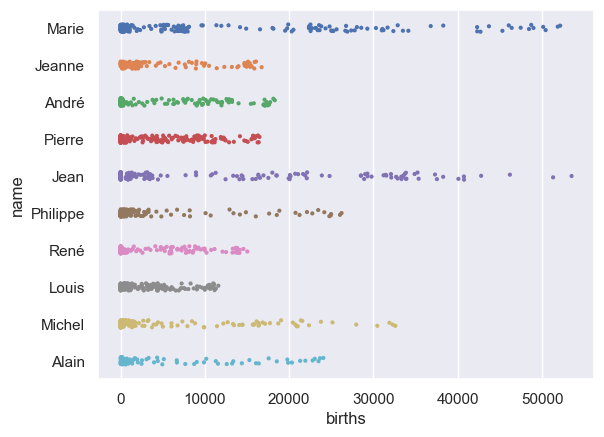

In [91]:
sns.stripplot(data=selection, x="births", y="name", hue="name", size=3, legend=False);

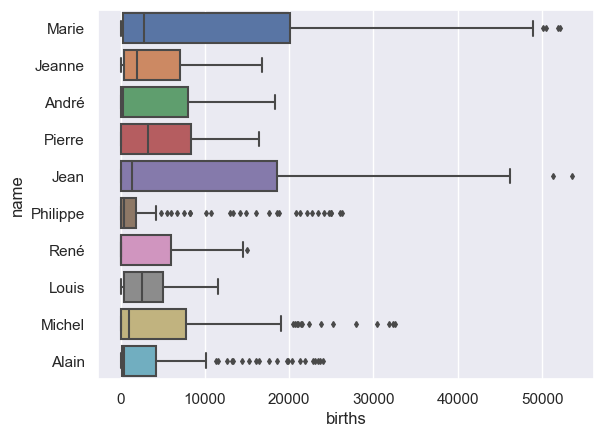

In [92]:
sns.boxplot(data=selection, x="births", y="name", fliersize=3);

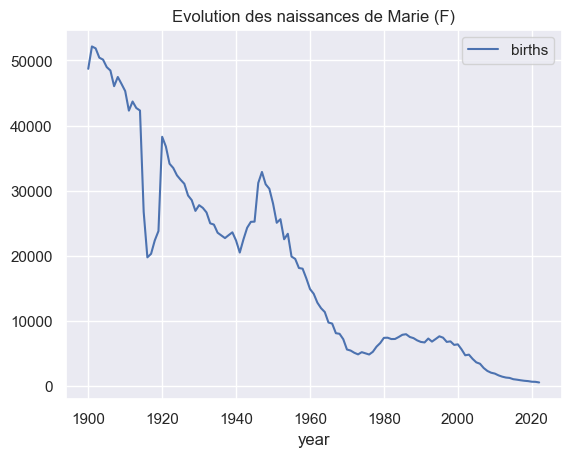

In [93]:
plot_name("Marie", "F")

In [109]:
cities = pd.read_csv("data/cities500.zip",
                     sep="\t",
                     names=['geonameid', 'name', 'asciiname', 'alternatenames', 'latitude', 'longitude', 'feature class', 'feature code', 'country code', 'cc2', 'admin1 code', 'admin2 code', 'admin3 code', 'admin4 code', 'population', 'elevation', 'dem', 'timezone', 'modification date'],
                     dtype={'admin1 code': str, 'admin2 code':str, 'admin3 code':str, 'admin4 code':str},
                     na_values=["", -9999],
                     keep_default_na=False
                    )
cities

,geonameid,name,asciiname,alternatenames,latitude,longitude,feature class,feature code,country code,cc2,admin1 code,admin2 code,admin3 code,admin4 code,population,elevation,dem,timezone,modification date
0,3038999,Soldeu,Soldeu,NaN,42.57688,1.66769,P,PPL,AD,NaN,02,NaN,NaN,NaN,602,NaN,1832.0,Europe/Andorra,2017-11-06
1,3039154,El Tarter,El Tarter,"Ehl Tarter,Эл Тартер",42.57952,1.65362,P,PPL,AD,NaN,02,NaN,NaN,NaN,1052,NaN,1721.0,Europe/Andorra,2012-11-03
2,3039163,Sant Julià de Lòria,Sant Julia de Loria,"San Julia,San Julià,Sant Julia de Loria,Sant J...",42.46372,1.49129,P,PPLA,AD,NaN,06,NaN,NaN,NaN,8022,NaN,921.0,Europe/Andorra,2013-11-23
3,3039604,Pas de la Casa,Pas de la Casa,"Pas de la Kasa,Пас де ла Каса",42.54277,1.73361,P,PPL,AD,NaN,03,NaN,NaN,NaN,2363,2050.0,2106.0,Europe/Andorra,2008-06-09
4,3039678,Ordino,Ordino,"Ordino,ao er di nuo,orudino jiao qu,Ордино,オルデ...",42.55623,1.53319,P,PPLA,AD,NaN,05,NaN,NaN,NaN,3066,NaN,1296.0,Europe/Andorra,2018-10-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199723,895269,Beitbridge,Beitbridge,"Bajtbridz,Bajtbridzh,Beitbridge,Beitbridzas,Be...",-22.21667,30.00000,P,PPL,ZW,NaN,07,NaN,NaN,NaN,58100,NaN,461.0,Africa/Harare,2022-10-07
199724,895308,Beatrice,Beatrice,Beatrice,-18.25283,30.84730,P,PPL,ZW,NaN,04,NaN,NaN,NaN,1647,NaN,1307.0,Africa/Harare,2018-05-09
199725,895417,Banket,Banket,"Banket,Banket Junction",-17.38333,30.40000,P,PPL,ZW,NaN,05,NaN,NaN,NaN,9641,NaN,1277.0,Africa/Harare,2013-03-12
199726,1085510,Epworth,Epworth,Epworth,-17.89000,31.14750,P,PPLX,ZW,NaN,10,NaN,NaN,NaN,123250,NaN,1508.0,Africa/Harare,2012-01-19


In [104]:
cities.select_dtypes('object').apply(lambda x: x.str.isdigit()).sum()

name                      0
asciiname                 0
alternatenames            0
feature class             0
feature code              0
country code              0
cc2                       0
admin1 code          163471
admin2 code          151198
admin3 code           85792
admin4 code           30229
timezone                  0
modification date         0
dtype: object

In [105]:
cities.isna().sum()

geonameid                 0
name                      0
asciiname                17
alternatenames        35663
latitude                  0
longitude                 0
feature class             0
feature code              0
country code              0
cc2                  199640
admin1 code              27
admin2 code           19930
admin3 code          108589
admin4 code          167083
population                0
elevation            166188
dem                       0
timezone                  0
modification date         0
dtype: int64

In [106]:
cities.loc[cities["country code"].isna()]

In [110]:
cities.describe()

,geonameid,latitude,longitude,population,elevation,dem
count,1.997280e+05,199728.000000,199728.000000,1.997280e+05,33540.000000,199507.000000
mean,3.566994e+06,32.289465,10.797871,1.837990e+04,294.865444,404.715403
std,2.457474e+06,21.881618,72.303464,1.964920e+05,362.312143,599.231634
min,2.960000e+03,-77.846320,-179.121980,0.000000e+00,-60.000000,-380.000000
25%,1.910535e+06,20.597485,-36.683888,5.930000e+02,67.000000,52.000000
50%,3.012648e+06,40.658140,10.341235,1.460000e+03,201.000000,182.000000
75%,4.256110e+06,47.527730,42.591675,5.458000e+03,348.250000,458.000000
max,1.254794e+07,78.223340,179.364510,2.231547e+07,3890.000000,5622.000000


In [116]:
cities["alternatenames"].str.split(",").str.len().mean()

5.173784780422394

In [117]:
def average_alternate_names(group):
    return group["alternatenames"].str.split(",").str.len().mean()

In [118]:
average_alternate_names(cities)

5.173784780422394

In [119]:
cities["feature code"].value_counts()

PPL      112734
PPLA3     28460
PPLA4     27038
PPLA2     20953
PPLX       6269
PPLA       3462
PPLL        391
PPLC        241
STLMT        46
PPLF         27
PPLQ         25
PPLA5        21
PPLS         21
PPLG         17
PPLH         13
PPLW          6
PPLR          3
PPLCH         1
Name: feature code, dtype: int64

In [124]:
var = pd.read_html("https://www.geonames.org/countries/", na_values="", keep_default_na=False)
[x.shape for x in var]

[(1, 2), (250, 9)]

In [125]:
countries = var[1]
countries

,ISO-3166 alpha2,ISO-3166 alpha3,ISO-3166 numeric,fips,Country,Capital,Area in km²,Population,Continent
0,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
1,AE,ARE,784,AE,United Arab Emirates,Abu Dhabi,82880.0,9630959,AS
2,AF,AFG,4,AF,Afghanistan,Kabul,647500.0,37172386,AS
3,AG,ATG,28,AC,Antigua and Barbuda,St. John's,443.0,96286,NA
4,AI,AIA,660,AV,Anguilla,The Valley,102.0,13254,NA
...,...,...,...,...,...,...,...,...,...
245,YE,YEM,887,YM,Yemen,Sanaa,527970.0,28498687,AS
246,YT,MYT,175,MF,Mayotte,Mamoudzou,374.0,279471,AF
247,ZA,ZAF,710,SF,South Africa,Pretoria,1219912.0,57779622,AF
248,ZM,ZMB,894,ZA,Zambia,Lusaka,752614.0,17351822,AF


In [126]:
countries.isna().sum()

ISO-3166 alpha2     0
ISO-3166 alpha3     0
ISO-3166 numeric    0
fips                3
Country             0
Capital             6
Area in km²         0
Population          0
Continent           0
dtype: int64

In [127]:
data = pd.merge(cities, countries, left_on="country code", right_on="ISO-3166 alpha2", how="left")
data

,geonameid,name,asciiname,alternatenames,latitude,longitude,feature class,feature code,country code,cc2,...,modification date,ISO-3166 alpha2,ISO-3166 alpha3,ISO-3166 numeric,fips,Country,Capital,Area in km²,Population,Continent
0,3038999,Soldeu,Soldeu,NaN,42.57688,1.66769,P,PPL,AD,NaN,...,2017-11-06,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
1,3039154,El Tarter,El Tarter,"Ehl Tarter,Эл Тартер",42.57952,1.65362,P,PPL,AD,NaN,...,2012-11-03,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
2,3039163,Sant Julià de Lòria,Sant Julia de Loria,"San Julia,San Julià,Sant Julia de Loria,Sant J...",42.46372,1.49129,P,PPLA,AD,NaN,...,2013-11-23,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
3,3039604,Pas de la Casa,Pas de la Casa,"Pas de la Kasa,Пас де ла Каса",42.54277,1.73361,P,PPL,AD,NaN,...,2008-06-09,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
4,3039678,Ordino,Ordino,"Ordino,ao er di nuo,orudino jiao qu,Ордино,オルデ...",42.55623,1.53319,P,PPLA,AD,NaN,...,2018-10-26,AD,AND,20,AN,Andorra,Andorra la Vella,468.0,77006,EU
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199723,895269,Beitbridge,Beitbridge,"Bajtbridz,Bajtbridzh,Beitbridge,Beitbridzas,Be...",-22.21667,30.00000,P,PPL,ZW,NaN,...,2022-10-07,ZW,ZWE,716,ZI,Zimbabwe,Harare,390580.0,14439018,AF
199724,895308,Beatrice,Beatrice,Beatrice,-18.25283,30.84730,P,PPL,ZW,NaN,...,2018-05-09,ZW,ZWE,716,ZI,Zimbabwe,Harare,390580.0,14439018,AF
199725,895417,Banket,Banket,"Banket,Banket Junction",-17.38333,30.40000,P,PPL,ZW,NaN,...,2013-03-12,ZW,ZWE,716,ZI,Zimbabwe,Harare,390580.0,14439018,AF
199726,1085510,Epworth,Epworth,Epworth,-17.89000,31.14750,P,PPLX,ZW,NaN,...,2012-01-19,ZW,ZWE,716,ZI,Zimbabwe,Harare,390580.0,14439018,AF


In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 199728 entries, 0 to 199727
Data columns (total 28 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   geonameid          199728 non-null  int64  
 1   name               199728 non-null  object 
 2   asciiname          199711 non-null  object 
 3   alternatenames     164065 non-null  object 
 4   latitude           199728 non-null  float64
 5   longitude          199728 non-null  float64
 6   feature class      199728 non-null  object 
 7   feature code       199728 non-null  object 
 8   country code       199728 non-null  object 
 9   cc2                88 non-null      object 
 10  admin1 code        199701 non-null  object 
 11  admin2 code        179798 non-null  object 
 12  admin3 code        91139 non-null   object 
 13  admin4 code        32645 non-null   object 
 14  population         199728 non-null  int64  
 15  elevation          33540 non-null   float64
 16  de

In [129]:
data["Continent"].value_counts()

EU    94167
AS    44503
NA    42576
SA     7408
OC     5957
AF     5114
AN        3
Name: Continent, dtype: int64

In [133]:
def largest_pop(group):
    return group.loc[group.population.idxmax(), ["name", "population"]]

In [134]:
largest_pop(data)

name          Shanghai
population    22315474
Name: 23416, dtype: object

In [135]:
data.groupby("Continent").apply(largest_pop)

,name,population
Continent,,
AF,Lagos,15388000
AN,McMurdo Station,1258
AS,Shanghai,22315474
EU,Moscow,10381222
NA,Mexico City,12294193
OC,Sydney,5231147
SA,São Paulo,12400232


In [138]:
data.isna().sum().to_frame().style.bar(color="lightgreen")

,0
geonameid,0
name,0
asciiname,17
alternatenames,35663
latitude,0
longitude,0
feature class,0
feature code,0
country code,0
cc2,199640


In [140]:
data.isna().sum().to_frame().style.background_gradient(cmap="Blues")

,0
geonameid,0
name,0
asciiname,17
alternatenames,35663
latitude,0
longitude,0
feature class,0
feature code,0
country code,0
cc2,199640


In [153]:
(cities[["name", "population", "elevation"]]
 .nlargest(20, "elevation")
 .style
 .bar(subset="population", color="lightgreen")
 .format(subset="elevation", precision=0)
 .background_gradient(subset="elevation", cmap="Blues")
 .to_html("test.html")
)